In [1]:
import caustics
from caustics import Module, forward, Param
from torch.nn.functional import conv2d, avg_pool2d

import numpy as np
import pandas as pd
import torch
from torch import pi
import matplotlib.pyplot as plt

import yaml
import torch
from scipy.stats import truncnorm
import pickle
#from tqdm.notebook import tqdm
#from tqdm.auto import tqdm
#from tqdm.auto import tqdm
#import tqdm as tqdm_module
#tqdm_module.tqdm.pandas()
from tqdm.notebook import tqdm


In [2]:
# Cosmology model
cosmology = caustics.FlatLambdaCDM(name="cosmo")

# PSF and image resolution
pixscale = 0.1  #0.11 / 2
fwhm = 0.1 # full width at half maximum of PSF
psf_sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
n_psf = 11
psf_image = caustics.utils.gaussian(nx=n_psf, ny=n_psf, pixelscale=pixscale, sigma=psf_sigma, upsample=1,)
N_pixels = 100

In [3]:
class Singlelens(Module):
    def __init__(self, lens, source, pixelscale, pixels_x, upsample_factor, psf=None, 
                 name: str = "sim", ):
        super().__init__(name)

        self.lens = lens
        self.src = source
        #self.lens_light = lens_light
        self.psf = Param("PSF", psf)
        self.upsample_factor = upsample_factor

        # Create the high-resolution grid
        thx, thy = caustics.utils.meshgrid(pixelscale / upsample_factor, upsample_factor * pixels_x,
            dtype=torch.float32,)

        self.thx = thx
        self.thy = thy

    @forward
    def run_simulator(self, psf):
        # Ray-trace to get the lensed positions
        bx, by = self.lens.raytrace(self.thx, self.thy)
        # Evaluate the lensed source brightness at high resolution
        image = self.src.brightness(bx, by)
        # Add the lens light
        #image += self.lens_light.brightness(self.thx, self.thy)
        # Downsample to the desired resolution
        image_ds = avg_pool2d(image[None, None], self.upsample_factor)[0, 0]
        # Convolve with the PSF using conv2d
        psf_normalized = (psf.T / psf.sum())[None, None]
        image_ds = (conv2d(image_ds[None, None], psf_normalized, padding="same").squeeze(0).squeeze(0))
        return image_ds

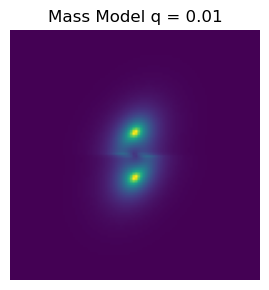

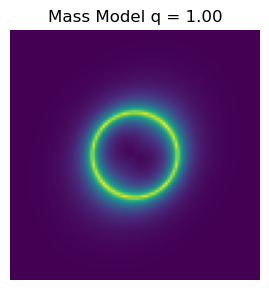

In [4]:
# Varying q for the lenss mass model
x = np.linspace(0.01, 1, 2, dtype=np.float32)

for i in range(len(x)):
    cx = x[i]
    
    # Mass model
    sie = caustics.SIE(cosmology=cosmology, name="lens", z_l=0.5, z_s=1.0, x0=0., y0=0.0, q=x[i], phi=0., Rein=1.7)
    # light source
    source_light = caustics.Sersic(name="source", x0=0, y0=0., q=0.7, phi=-0.985, n=1.3, Re=1.0, Ie=5) #
    
    # Instantiate simulator
    simulator = Singlelens(lens=sie, source=source_light, pixels_x=N_pixels, pixelscale=pixscale,
        upsample_factor=1, psf=psf_image, )

    # Set all parameters to be dynamic
    simulator.to_dynamic(children_only=False)
    cosmology.to_static()  # except cosmology parameters

    # Now create a flattened tensor
    params_for_simulator = simulator.get_values()
    lensed_image = simulator.run_simulator(params_for_simulator)

    title = 'Mass Model q = {:.2f}'.format(x[i])
    plt.figure(figsize = (3,3))
    plt.title(title, fontsize=12)
    plt.imshow(lensed_image)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('for_gif/lens_' + str(i) + '.png')
    plt.show()
    plt.close()
    

In [5]:
def plot_simulation(lensed_image):
    #title = 'Mass Model q = {:.2f}'.format(x[i])
    plt.figure(figsize = (3,3))
    #plt.title(title, fontsize=12)
    plt.imshow(lensed_image)
    plt.axis('off')
    plt.tight_layout()
    #plt.savefig('for_gif/lens_' + str(i) + '.png')
    plt.show()
    plt.close()

def one_simulation(sie_params, source_params):
    sie = caustics.SIE(cosmology=cosmology, name="lens", **sie_params)
    source_light = caustics.Sersic(name="source", **source_params) #
    simulator = Singlelens(lens=sie, source=source_light, pixels_x=N_pixels, pixelscale=pixscale,
        upsample_factor=1, psf=psf_image, )

    simulator.to_dynamic(children_only=False)
    cosmology.to_static()  

    params_for_simulator = simulator.get_values()
    lensed_image = simulator.run_simulator(params_for_simulator)
    return(lensed_image)

In [6]:
# Physical bounds for each parameter
PHYSICAL_BOUNDS = {
    'sie': {
        'z_l': (0.0, None),
        'z_s': (0.0, None),
        'q':    (0.4, 1.0),
        'Rein': (0.0, None),   # must be positive
        'phi':  (0.0, 2 * torch.pi),
    },
    'source': {
        'q':    (0.4, 1.0),
        'n':    (0.36000001430511475, 10.0),
        'Re':   (0.0, None),   # must be positive
        'phi':  (0.0, 2 * torch.pi),
        'Ie':   (0.0, None),   # must be positive
    },
}

def is_physical(sie_params, source_params, verbose=True):
    """
    Check that sampled parameters are within physical bounds.
    Returns True if all parameters are valid, False otherwise.
    """
    all_valid = True

    checks = [
        ('sie',    sie_params),
        ('source', source_params),
    ]

    for group_name, params in checks:
        bounds = PHYSICAL_BOUNDS[group_name]
        for param, (lo, hi) in bounds.items():
            if param not in params:
                continue
            val = params[param]
            if lo is not None and val < lo:
                if verbose:
                    print(f"[INVALID] {group_name}.{param} = {val:.4f} < min {lo}")
                all_valid = False
            if hi is not None and val > hi:
                if verbose:
                    print(f"[INVALID] {group_name}.{param} = {val:.4f} > max {hi}")
                all_valid = False

    return all_valid

In [7]:
def load_config(config_path):
    with open(config_path, 'r') as f:
        return yaml.safe_load(f)

def sample_param(spec):
    """Sample a single parameter from its distribution spec (dict with min/max or mean/std)."""
    if 'min' in spec and 'max' in spec:
        # Uniform distribution
        return spec['min'] + (spec['max'] - spec['min']) * torch.rand(()).item()
    elif 'mean' in spec and 'std' in spec:
        if spec['std'] == 0.0:
            return spec['mean']
        # Gaussian (unconstrained)
        return torch.normal(mean=spec['mean'], std=spec['std'], size=()).item()
    else:
        raise ValueError(f"Unrecognised param spec: {spec}")

def sample_params_from_config(config_path='config_files/sersic-sie.yaml'):
    cfg = load_config(config_path)
    dataset_cfg = cfg['dataset']

    lens_p = dataset_cfg['lens']['params']
    source_p = dataset_cfg['source']['params']

    sie_params = {
        'z_l': sample_param(lens_p['z']),
        'z_s': sample_param(source_p['z']),
        'x0':  sample_param(lens_p['mass']['x0']),
        'y0':  sample_param(lens_p['mass']['y0']),
        'q':   sample_param(lens_p['mass']['q']),
        'phi': sample_param(lens_p['mass']['phi']),
        'Rein':sample_param(lens_p['mass']['Rein']),
    }

    source_params = {
        'x0':  sample_param(source_p['x0']),
        'y0':  sample_param(source_p['y0']),
        'q':   sample_param(source_p['q']),
        'phi': sample_param(source_p['phi']),
        'n':   sample_param(source_p['n']),
        'Re':  sample_param(source_p['Re']),
        'Ie':  sample_param(source_p['Ie']),
    }

    return sie_params, source_params




In [8]:
# Run simulations
def create_simulations(N_sim):
    images = []
    data_sie, data_source = [], []
    
    with tqdm(total=N_sim, display=True) as pbar:
        n = 0
        while n < N_sim:
            sie_params, source_params = sample_params_from_config('config_files/sersic-sie.yaml')
            if is_physical(sie_params, source_params, verbose=False):
                lensed_image = one_simulation(sie_params, source_params)
                images.append(lensed_image)
                data_sie.append(sie_params)
                data_source.append(source_params)
                n += 1
                pbar.update(1)
                pbar.refresh()

    data_sie = pd.DataFrame(data_sie)
    data_source = pd.DataFrame(data_source)
    data_sie = data_sie.drop(['z_l', 'z_s'], axis=1)
    data_sie.columns = [col + '_mass' for col in data_sie.columns]
    data_source.columns = [col + '_source' for col in data_source.columns]
    data = pd.concat([data_sie, data_source], axis=1)

    return images, data


In [9]:
%matplotlib inline
N_sim = 5000
images, data = create_simulations(N_sim)

exp = 2
data.to_csv('data/data' + str(exp) + '.csv', index=False)
np.save('data/images' + str(exp) + '.npy', np.stack([img.detach().numpy() for img in images]))
    
#loading data
data = pd.read_csv('data/data.csv')
images = list(np.load('data/images.npy'))


  0%|          | 0/5000 [00:00<?, ?it/s]